# FashionMNIST Classifier Workshop

Welcome to this PyTorch workshop! Your goal is to build an Artificial Neural Network that can classify images of clothing.

We have set up the data loading and training loops for you. Your job is to design the architecture of the brain (the model) in **Step 4**.

Let's get started!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 5

print("Libraries loaded successfully!")


Libraries loaded successfully!


### Step 1: Downloading and Loading FashionMNIST
We are using `torchvision` to download our datasets. We need a training set to teach the model, and a testing set to evaluate it later.


In [ ]:
# Convert images to PyTorch Tensors
transform = transforms.Compose([transforms.ToTensor()])

# Download Training Data
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Download Testing Data
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Loaded {len(train_dataset)} training images and {len(test_dataset)} testing images.")


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.98MB/s]

Loaded 60000 training images and 10000 testing images.


### Step 2: Peeking at the Wardrobe
Let's see what our data actually looks like. FashionMNIST uses numbers 0-9 as labels. We need a dictionary to translate those numbers back into human-readable clothing items.


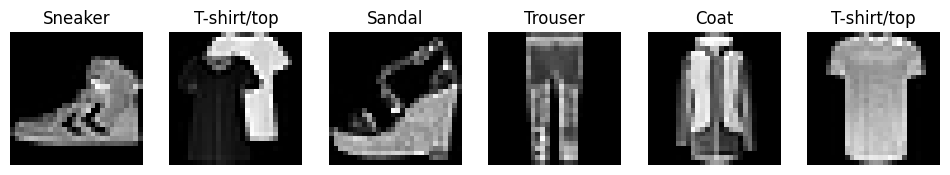

In [ ]:
# FashionMNIST class labels
classes = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

# Grab one batch of data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Plot 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    img = images[i].squeeze() # Remove channel dimension for matplotlib
    label_idx = labels[i].item()

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(classes[label_idx])
    axes[i].axis('off')

plt.show()


### Step 3: YOUR TURN - Design the Model

This is the core task! Build a Feed-Forward Neural Network to classify the clothing items.

**Things to remember:**
1. Your input images are 28x28 pixels.
2. The network needs to "flatten" this into a 1D array of 784 pixels.
3. You have 10 possible clothing categories as your final output.


In [ ]:
class FashionClassifier(nn.Module):
    def __init__(self):
        super(FashionClassifier, self).__init__()

        # TODO: 1. Create a Flatten layer to turn the 2D image into a 1D vector

        self.flatten = nn.Flatten()

        # TODO: 2. Create your hidden Linear (fully connected) layers.
        self.fc1 = nn.Linear(784, 128)
        # Hint: The first layer must accept 28 * 28 inputs!
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128,256)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(256, 128)

        self.relu3 = nn.ReLU()

        # TODO: 3. Create your activation functions (e.g., nn.ReLU())

        # TODO: 4. Create your final output layer.
        # Hint: How many classes of clothing are there?
        self.output = nn.Linear(128, 10)

        # pass # Remove this 'pass' when you write your code!

    def forward(self, x):
        # TODO: Pass 'x' through the layers you defined in __init__
        # Example: x = self.flatten(x)
        # Remember to return the final output!
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)
        x = self.relu3(x)

        x = self.output(x)

        return x

# Instantiate your model
model = FashionClassifier()
print("Model created!")


Model created!


### Step 4: Setting up the Engine (Loss & Optimizer)
We need a way to measure how wrong the model is (Loss) and an algorithm to adjust the weights to make it better (Optimizer).


In [ ]:
# We use CrossEntropyLoss for multi-class classification
criterion = nn.CrossEntropyLoss()

# The optimizer updates the weights in your model
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


### Step 5: The Training Loop
This is where the actual learning happens. Watch the loss decrease over time!


In [ ]:
print("Starting Training...")

for epoch in range(EPOCHS):
    running_loss = 0.0

    for images, labels in train_loader:
        # 1. Clear old gradients
        optimizer.zero_grad()

        # 2. Forward pass: Model makes a guess
        outputs = model(images)

        # 3. Calculate how wrong the guess was
        loss = criterion(outputs, labels)

        # 4. Backward pass: Calculate gradients
        loss.backward()

        # 5. Step: Update weights
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

print("Training Complete!")


Starting Training...
Epoch [1/5], Loss: 0.5448
Epoch [2/5], Loss: 0.3733
Epoch [3/5], Loss: 0.3349
Epoch [4/5], Loss: 0.3119
Epoch [5/5], Loss: 0.2924
Training Complete!


### Step 6: Testing the Model
Let's see how well your architecture performs on data it has never seen before.

**Goal: Can you tweak your model in Step 3 to get over 85% accuracy?**


In [ ]:
model.eval() # Put model in testing mode
correct = 0
total = 0

# Turn off gradients to save memory and speed up testing
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)

        # Get the index of the highest probability
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Final Test Accuracy: {accuracy:.2f}%")


Final Test Accuracy: 87.64%



--- Prediction Result ---
The model thinks this is a: **Bag**


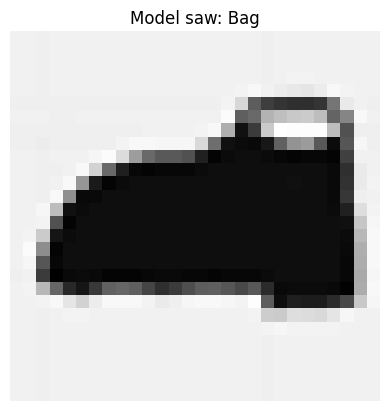

In [ ]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch

def predict_my_clothing(image_path, trained_model):
    # 1. Define the clothing labels
    classes = {
        0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
        5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
    }

    # 2. Load the image
    img = Image.open(image_path)

    # 3. Preprocess the image
    # Convert to grayscale
    img = img.convert('L')


    # INVERT COLORS: FashionMNIST has a black background and white clothing.
    # If your photo has a light background and dark clothing, keep this line.
    # If your photo is already on a dark background, comment this line out!
    img = ImageOps.invert(img)

    # Resize to 28x28 pixels
    img = img.resize((28, 28))

    # Convert to tensor and scale to [0, 1]
    transform = transforms.ToTensor()
    img_tensor = transform(img)

    # Add a batch dimension: [1, 28, 28] becomes [1, 1, 28, 28]
    img_tensor = img_tensor.unsqueeze(0)

    # 4. Make the prediction
    trained_model.eval()
    with torch.no_grad():
        output = trained_model(img_tensor)
        _, predicted_idx = torch.max(output, 1)

    predicted_label = classes[predicted_idx.item()]


    # INVERT COLORS: FashionMNIST has a black background and white clothing.
    # If your photo has a light background and dark clothing, keep this line.
    # If your photo is already on a dark background, comment this line out!
    img = ImageOps.invert(img)

    # Resize to 28x28 pixels
    img = img.resize((28, 28))

    # Convert to tensor and scale to [0, 1]
    transform = transforms.ToTensor()
    img_tensor = transform(img)

    # Add a batch dimension: [1, 28, 28] becomes [1, 1, 28, 28]
    img_tensor = img_tensor.unsqueeze(0)

    # 4. Make the prediction
    trained_model.eval()
    with torch.no_grad():
        output = trained_model(img_tensor)
        _, predicted_idx = torch.max(output, 1)

    predicted_label = classes[predicted_idx.item()]

    # 5. Show the results
    print(f"\n--- Prediction Result ---")
    print(f"The model thinks this is a: **{predicted_label}**")

    # Show what the model actually "saw"
    plt.imshow(img_tensor.squeeze(), cmap='gray')
    plt.title(f"Model saw: {predicted_label}")
    plt.axis('off')
    plt.show()

# --- HOW TO USE IT ---
# 1. Upload an image named 'my_shirt.jpg' to your Google Colab or your working folder.
# 2. Uncomment the line below to run it!

predict_my_clothing('Screenshot 2026-08-25 at 2.36.41 PM.png', model)